In [1]:
import pandas as pd
import numpy as np
import os
import json
import time
import warnings
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    precision_score,
    recall_score
)

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Directories
os.makedirs('../models/binary', exist_ok=True)
os.makedirs('../results/binary', exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

# Load NEW binary split artifacts
print("\nLoading binary split data...")
X_train = pd.read_csv('../extracted/X_train_binary.csv')
X_val   = pd.read_csv('../extracted/X_val_binary.csv')
X_test  = pd.read_csv('../extracted/X_test_binary.csv')

y_train = pd.read_csv('../extracted/y_train_binary.csv').squeeze()
y_val   = pd.read_csv('../extracted/y_val_binary.csv').squeeze()
y_test  = pd.read_csv('../extracted/y_test_binary.csv').squeeze()

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

# Convert to numpy
X_train_np = X_train.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)

y_train_np = y_train.values.astype(np.float32)
y_val_np   = y_val.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)

# Input dimension
n_features = X_train_np.shape[1]
print(f"Number of features: {n_features}")

# Class weights based on actual imbalance
neg, pos = np.bincount(y_train.astype(int))
total = neg + pos

class_weight = {
    0: total / (2.0 * neg),
    1: total / (2.0 * pos)
}

print(f"\nTrain class counts -> benign(0): {neg}, attack(1): {pos}")
print(f"Computed class_weight: {class_weight}")

TensorFlow: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Loading binary split data...
Train: (14703605, 39)
Val:   (2100516, 39)
Test:  (4201031, 39)
Number of features: 39

Train class counts -> benign(0): 733115, attack(1): 13970490
Computed class_weight: {0: 10.028170887241428, 1: 0.5262379844944594}


In [2]:
def compute_binary_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'precision_benign': precision_score(y_true, y_pred, pos_label=0),
        'recall_benign': recall_score(y_true, y_pred, pos_label=0),
        'precision_attack': precision_score(y_true, y_pred, pos_label=1),
        'recall_attack': recall_score(y_true, y_pred, pos_label=1),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'fpr': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        'fnr': fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp)
    }
    return metrics

In [3]:
# === MODEL 1: MLP ===
print("Building MLP...")

mlp = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
], name='MLP')

optimizer = keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)

mlp.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mlp.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_mlp = keras.callbacks.ModelCheckpoint(
    filepath='../models/binary/mlp_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("\nTraining MLP...")
t0 = time.time()

history_mlp = mlp.fit(
    X_train_np, y_train_np,
    epochs=10,
    batch_size=4096,
    validation_data=(X_val_np, y_val_np),
    class_weight=class_weight,
    callbacks=[early_stop, checkpoint_mlp],
    verbose=1
)

mlp_time = time.time() - t0
print(f"\nTraining time: {mlp_time:.1f}s")

Building MLP...


2026-04-08 16:47:39.390392: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-08 16:47:39.390594: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-08 16:47:39.390626: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-04-08 16:47:39.390830: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-08 16:47:39.390857: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,993 (207.00 KB)

 Trainable params: 52,225 (204.00 KB)

 Non-trainable params: 768 (3.00 KB)


Training MLP...
Epoch 1/10


2026-04-08 16:47:43.645823: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


3590/3590 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7640 - loss: 0.3933
Epoch 1: val_loss improved from None to 0.17325, saving model to ../models/binary/mlp_best.keras
3590/3590 ━━━━━━━━━━━━━━━━━━━━ 65s 18ms/step - accuracy: 0.8585 - loss: 0.2690 - val_accuracy: 0.9508 - val_loss: 0.1733
Epoch 2/10
3588/3590 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9515 - loss: 0.1257
Epoch 2: val_loss improved from 0.17325 to 0.16069, saving model to ../models/binary/mlp_best.keras
3590/3590 ━━━━━━━━━━━━━━━━━━━━ 62s 17ms/step - accuracy: 0.9520 - loss: 0.1222 - val_accuracy: 0.9514 - val_loss: 0.1607
Epoch 3/10
3590/3590 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9530 - loss: 0.1144
Epoch 3: val_loss improved from 0.16069 to 0.15561, saving model to ../models/binary/mlp_best.keras
3590/3590 ━━━━━━━━━━━━━━━━━━━━ 62s 17ms/step - accuracy: 0.9530 - loss: 0.1130 - val_accuracy: 0.9515 - val_loss: 0.1556
Epoch 4/10
3588/3590 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9531 - loss: 0.

In [4]:
print(f"X_train: {X_train_np.shape}")
print(f"X_test: {X_test_np.shape}")
print(f"MLP exists: {mlp is not None}")

X_train: (14703605, 39)
X_test: (4201031, 39)
MLP exists: True


In [5]:
# === MODEL 2: 1D CNN ===
print("Building 1D CNN...")

X_train_cnn = X_train_np.reshape(-1, n_features, 1)
X_val_cnn   = X_val_np.reshape(-1, n_features, 1)
X_test_cnn  = X_test_np.reshape(-1, n_features, 1)

cnn = keras.Sequential([
    layers.Input(shape=(n_features, 1)),
    layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
], name='CNN_1D')

optimizer_cnn = keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)

cnn.compile(
    optimizer=optimizer_cnn,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

early_stop_cnn = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_cnn = keras.callbacks.ModelCheckpoint(
    filepath='../models/binary/cnn_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("\nTraining 1D CNN...")
t0 = time.time()

history_cnn = cnn.fit(
    X_train_cnn, y_train_np,
    epochs=10,
    batch_size=4096,
    validation_data=(X_val_cnn, y_val_np),
    class_weight=class_weight,
    callbacks=[early_stop_cnn, checkpoint_cnn],
    verbose=1
)

cnn_time = time.time() - t0
print(f"\nTraining time: {cnn_time:.1f}s")

Building 1D CNN...


Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 39, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 39, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 19, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 9, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 9, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,585 (389.00 KB)

 Trainable params: 99,201 (387.50 KB)

 Non-trainable params: 384 (1.50 KB)


Training 1D CNN...
Epoch 1/10
3590/3590 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9477 - loss: 0.1562
Epoch 1: val_loss improved from None to 0.17290, saving model to ../models/binary/cnn_best.keras
3590/3590 ━━━━━━━━━━━━━━━━━━━━ 119s 33ms/step - accuracy: 0.9536 - loss: 0.1273 - val_accuracy: 0.9516 - val_loss: 0.1729
Epoch 2/10
3589/3590 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9549 - loss: 0.0964
Epoch 2: val_loss improved from 0.17290 to 0.14306, saving model to ../models/binary/cnn_best.keras
3590/3590 ━━━━━━━━━━━━━━━━━━━━ 116s 32ms/step - accuracy: 0.9548 - loss: 0.0945 - val_accuracy: 0.9516 - val_loss: 0.1431
Epoch 3/10
3590/3590 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9550 - loss: 0.0926
Epoch 3: val_loss improved from 0.14306 to 0.13625, saving model to ../models/binary/cnn_best.keras
3590/3590 ━━━━━━━━━━━━━━━━━━━━ 119s 33ms/step - accuracy: 0.9549 - loss: 0.0930 - val_accuracy: 0.9527 - val_loss: 0.1362
Epoch 4/10
3590/3590 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/

In [6]:
# === EVALUATE MLP ===
print("Evaluating MLP...")
mlp_pred_prob = mlp.predict(X_test_np, batch_size=4096, verbose=1).flatten()
mlp_pred = (mlp_pred_prob > 0.5).astype(int)

mlp_metrics = compute_binary_metrics(y_test_np, mlp_pred, mlp_pred_prob)

print(f"\n=== MLP RESULTS ===")
for k, v in mlp_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print(classification_report(
    y_test_np, mlp_pred,
    target_names=['Benign', 'Attack'],
    digits=4
))

# === EVALUATE CNN ===
print("\nEvaluating 1D CNN...")
cnn_pred_prob = cnn.predict(X_test_cnn, batch_size=4096, verbose=1).flatten()
cnn_pred = (cnn_pred_prob > 0.5).astype(int)

cnn_metrics = compute_binary_metrics(y_test_np, cnn_pred, cnn_pred_prob)

print(f"\n=== 1D CNN RESULTS ===")
for k, v in cnn_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print(classification_report(
    y_test_np, cnn_pred,
    target_names=['Benign', 'Attack'],
    digits=4
))

Evaluating MLP...
1026/1026 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

=== MLP RESULTS ===
accuracy: 0.9520
f1_weighted: 0.9591
f1_macro: 0.8244
precision_benign: 0.5093
recall_benign: 0.9997
precision_attack: 1.0000
recall_attack: 0.9495
roc_auc: 0.9883
pr_auc: 0.9994
mcc: 0.6953
fpr: 0.0003
fnr: 0.0505
tn: 209397
fp: 65
fn: 201736
tp: 3789833
              precision    recall  f1-score   support

      Benign     0.5093    0.9997    0.6748    209462
      Attack     1.0000    0.9495    0.9741   3991569

    accuracy                         0.9520   4201031
   macro avg     0.7546    0.9746    0.8244   4201031
weighted avg     0.9755    0.9520    0.9591   4201031


Evaluating 1D CNN...
1026/1026 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step

=== 1D CNN RESULTS ===
accuracy: 0.9529
f1_weighted: 0.9599
f1_macro: 0.8270
precision_benign: 0.5145
recall_benign: 0.9998
precision_attack: 1.0000
recall_attack: 0.9505
roc_auc: 0.9897
pr_auc: 0.9995
mcc: 0.6992
fpr: 0.0002
fnr: 0.0495
tn: 209414
fp: 48
fn: 197638
tp

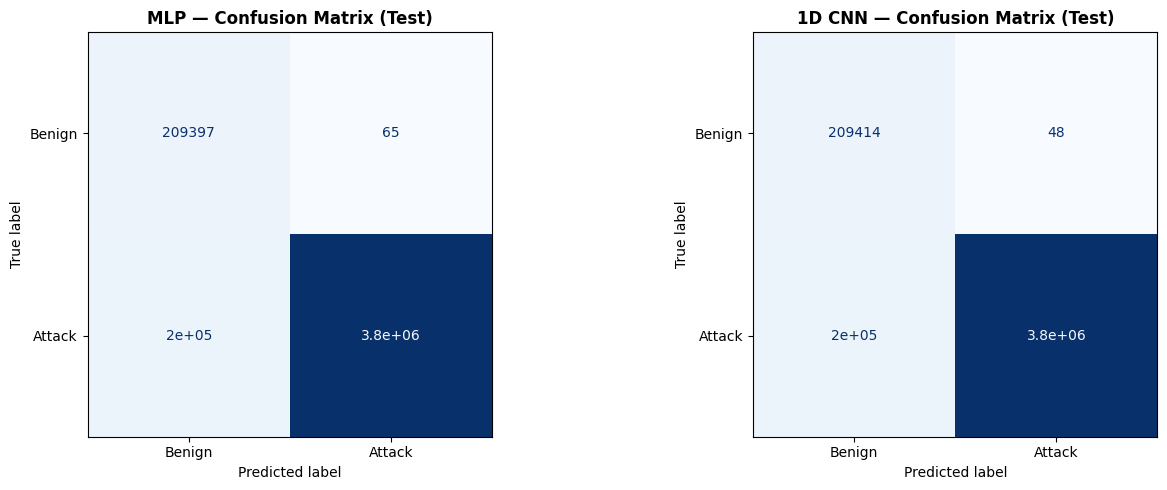

Saved: ../results/binary/dl_confusion_matrices_binary.png

=== DL BASELINE RESULTS ===
 Model Type  Accuracy  F1 Weighted  F1 Macro  ROC-AUC   PR-AUC      MCC  Benign Precision  Benign Recall  Attack Precision  Attack Recall      FPR      FNR  Train Time(s)
   MLP   DL  0.951964     0.959146  0.824447 0.988287 0.999394 0.695271          0.509317       0.999690          0.999983       0.949459 0.000310 0.050541     636.919677
1D CNN   DL  0.952943     0.959887  0.826979 0.989661 0.999464 0.699187          0.514465       0.999771          0.999987       0.950486 0.000229 0.049514     707.579320

Saved: ../results/binary/dl_baseline_results_binary.csv


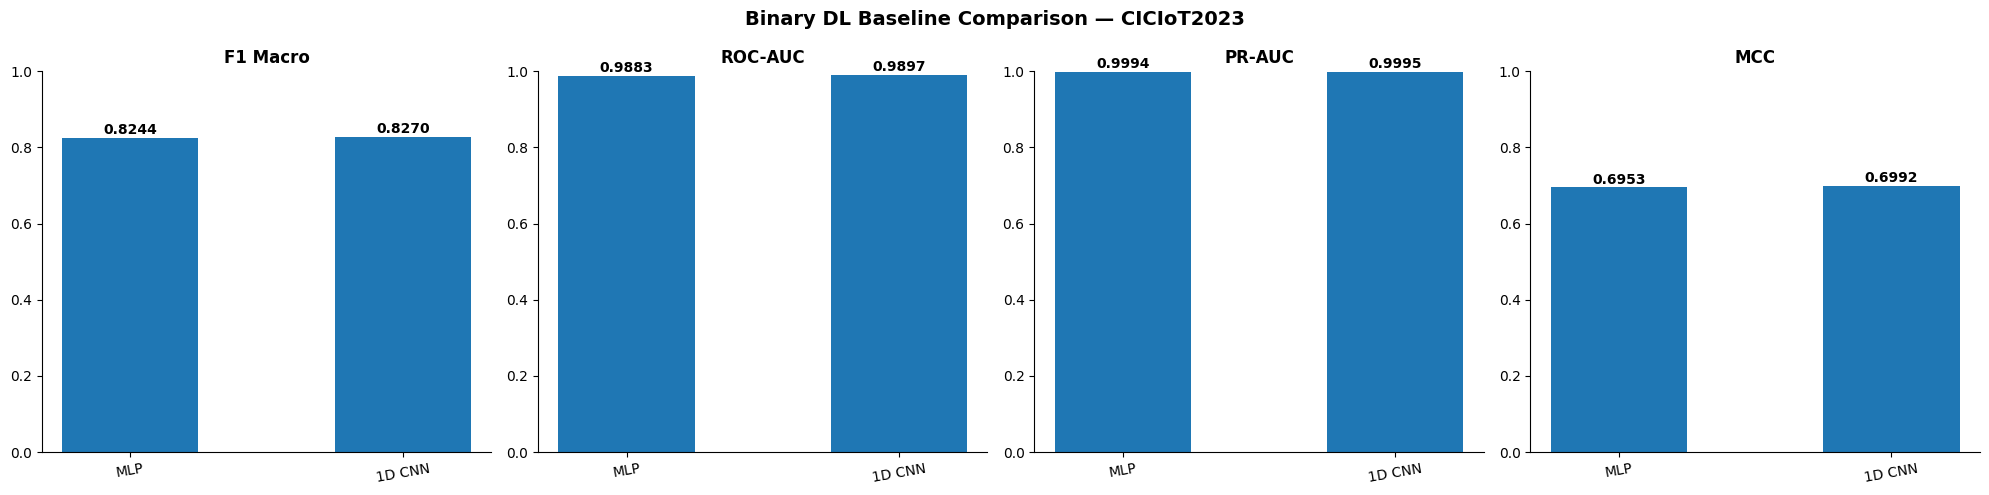

Saved: ../results/binary/dl_baseline_comparison_binary.png

Saved: ../models/binary/mlp_model.keras
Saved: ../models/binary/cnn_model.keras
Saved: ../results/binary/dl_training_history.json


In [7]:
import json

# === CONFUSION MATRICES ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(
    axes,
    [mlp_pred, cnn_pred],
    ['MLP', '1D CNN']
):
    cm = confusion_matrix(y_test_np, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Attack'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} — Confusion Matrix (Test)', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/binary/dl_confusion_matrices_binary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/binary/dl_confusion_matrices_binary.png")

# === DL RESULTS TABLE ===
dl_results = [
    {
        'Model': 'MLP',
        'Type': 'DL',
        'Accuracy': mlp_metrics['accuracy'],
        'F1 Weighted': mlp_metrics['f1_weighted'],
        'F1 Macro': mlp_metrics['f1_macro'],
        'ROC-AUC': mlp_metrics['roc_auc'],
        'PR-AUC': mlp_metrics['pr_auc'],
        'MCC': mlp_metrics['mcc'],
        'Benign Precision': mlp_metrics['precision_benign'],
        'Benign Recall': mlp_metrics['recall_benign'],
        'Attack Precision': mlp_metrics['precision_attack'],
        'Attack Recall': mlp_metrics['recall_attack'],
        'FPR': mlp_metrics['fpr'],
        'FNR': mlp_metrics['fnr'],
        'Train Time(s)': mlp_time
    },
    {
        'Model': '1D CNN',
        'Type': 'DL',
        'Accuracy': cnn_metrics['accuracy'],
        'F1 Weighted': cnn_metrics['f1_weighted'],
        'F1 Macro': cnn_metrics['f1_macro'],
        'ROC-AUC': cnn_metrics['roc_auc'],
        'PR-AUC': cnn_metrics['pr_auc'],
        'MCC': cnn_metrics['mcc'],
        'Benign Precision': cnn_metrics['precision_benign'],
        'Benign Recall': cnn_metrics['recall_benign'],
        'Attack Precision': cnn_metrics['precision_attack'],
        'Attack Recall': cnn_metrics['recall_attack'],
        'FPR': cnn_metrics['fpr'],
        'FNR': cnn_metrics['fnr'],
        'Train Time(s)': cnn_time
    }
]

dl_results_df = pd.DataFrame(dl_results)
dl_results_df.to_csv('../results/binary/dl_baseline_results_binary.csv', index=False)

print("\n=== DL BASELINE RESULTS ===")
print(dl_results_df.to_string(index=False))
print("\nSaved: ../results/binary/dl_baseline_results_binary.csv")

# === DL COMPARISON PLOT ===
metrics = ['F1 Macro', 'ROC-AUC', 'PR-AUC', 'MCC']
models = dl_results_df['Model'].tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, metric in zip(axes, metrics):
    vals = dl_results_df[metric].tolist()
    bars = ax.bar(models, vals, width=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis='x', rotation=10)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.4f}',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Binary DL Baseline Comparison — CICIoT2023', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/binary/dl_baseline_comparison_binary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: ../results/binary/dl_baseline_comparison_binary.png")

# === SAVE FINAL MODELS ===
mlp.save('../models/binary/mlp_model.keras')
cnn.save('../models/binary/cnn_model.keras')

print("\nSaved: ../models/binary/mlp_model.keras")
print("Saved: ../models/binary/cnn_model.keras")

# === SAVE TRAINING HISTORY ===
history_bundle = {
    'mlp_history': history_mlp.history,
    'cnn_history': history_cnn.history
}
with open('../results/binary/dl_training_history.json', 'w') as f:
    json.dump(history_bundle, f, indent=2)

print("Saved: ../results/binary/dl_training_history.json")